In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")

print("Path to dataset files:", path)

100%|██████████| 82.0M/82.0M [00:04<00:00, 17.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1


In [ ]:
# Cell 2.6: Find where the actual .npy files are
import os
import glob

data_path = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1"

print(f"Searching in: {data_path}")
print("-" * 50)

# List everything in the directory (first level)
print("\n📁 First-level contents:")
!ls -la "{data_path}"

# Recursively search for ANY .npy file
all_npy_files = glob.glob(os.path.join(data_path, "**", "*.npy"), recursive=True)

print(f"\n📊 Total .npy files found recursively: {len(all_npy_files)}")

if len(all_npy_files) > 0:
    # Show the first few files to understand the structure
    print("\n📄 First 5 .npy files found:")
    for f in all_npy_files[:5]:
        print(f"  - {f}")

    # Extract the directory that contains these files
    smap_path = os.path.dirname(all_npy_files[0])
    print(f"\n✅ The files are actually in: {smap_path}")

    # Also check if there's an MSL folder
    msl_files = [f for f in all_npy_files if "MSL" in f or "msl" in f]
    print(f"MSL files found: {len(msl_files)}")

else:
    print("\n❌ No .npy files found anywhere!")
    print("   The download might have failed or the dataset structure is different.")
    print("   Try running this to see the full directory tree:")
    print("   !find '{data_path}' -type f")

Searching in: /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1
--------------------------------------------------

📁 First-level contents:
total 16
drwxr-xr-x 3 root root 4096 Jun 26 05:29 .
drwxr-xr-x 3 root root 4096 Jun 26 05:29 ..
drwxr-xr-x 3 root root 4096 Jun 26 05:29 data
-rw-r--r-- 1 root root 3956 Jun 26 05:29 labeled_anomalies.csv

📊 Total .npy files found recursively: 328

📄 First 5 .npy files found:
  - /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/test/E-6.npy
  - /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/test/G-6.npy
  - /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/test/P-15.npy
  - /root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/test/M-7.npy
  - /root/.cache/kagglehub/datasets/pat

In [ ]:
# Cell 2.7: Explore the full dataset structure
import os

base = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1"

print("📁 Full structure:")
!ls -R "{base}/data/data"

# Check if there's a test folder anywhere
test_files = !find "{base}" -type d -name "test" -o -name "val"
print("\n🔍 Folders named 'test' or 'val':")
print(test_files)

📁 Full structure:
/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data:
2018-05-19_15.00.10  test  train

/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/2018-05-19_15.00.10:
models	params.log  smoothed_errors  y_hat

/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/2018-05-19_15.00.10/models:
A-1.h5	C-1.h5	 D-3.h5   E-13.h5  F-1.h5  G-4.h5  P-10.h5  S-1.h5   T-8.h5
A-2.h5	C-2.h5	 D-4.h5   E-1.h5   F-2.h5  G-6.h5  P-11.h5  S-2.h5   T-9.h5
A-3.h5	D-11.h5  D-5.h5   E-2.h5   F-3.h5  G-7.h5  P-14.h5  T-10.h5
A-4.h5	D-12.h5  D-6.h5   E-3.h5   F-4.h5  M-1.h5  P-15.h5  T-12.h5
A-5.h5	D-13.h5  D-7.h5   E-4.h5   F-5.h5  M-2.h5  P-1.h5   T-13.h5
A-6.h5	D-14.h5  D-8.h5   E-5.h5   F-7.h5  M-3.h5  P-2.h5   T-1.h5
A-7.h5	D-15.h5  D-9.h5   E-6.h5   F-8.h5  M-4.h5  P-3.h5   T-2.h5
A-8.h5	D-16.h5  E-10.h5  E-7.h5   G-1.h5  M-5.h5  P-4

Found 82 sensor channel files in the train folder.

✅ Successfully computed variances for 82 channels.
   Min variance: 0.0054
   Max variance: 0.0636
   Mean variance: 0.0341


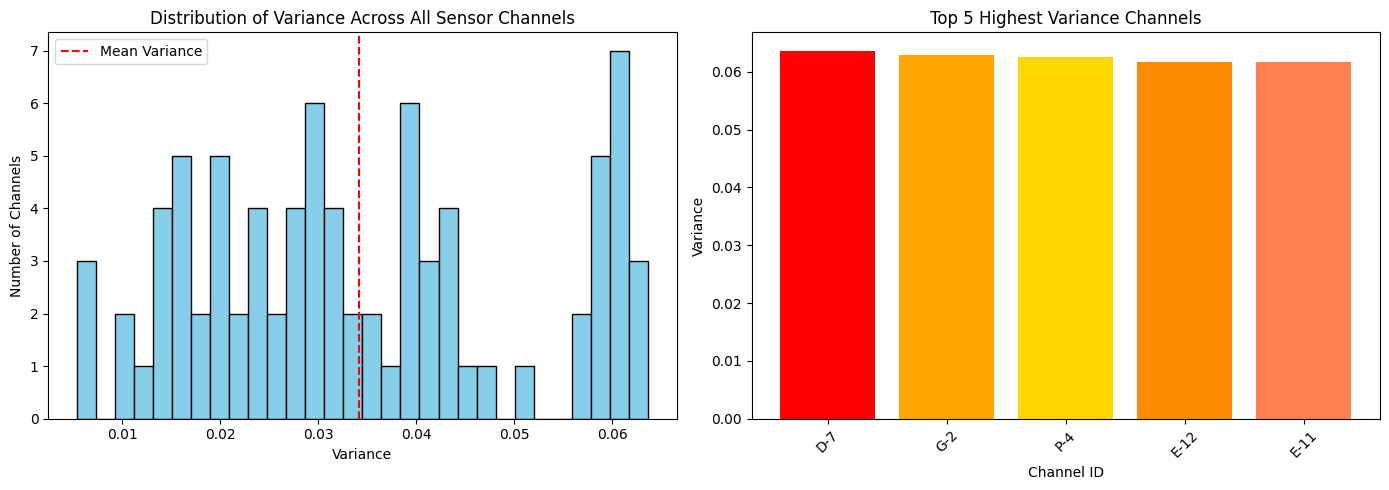


📊 Top 5 high-variance channels: ['D-7', 'G-2', 'P-4', 'E-12', 'E-11']
   Variances: [np.float64(0.06363531527577873), np.float64(0.0628303264693793), np.float64(0.06253381541413756), np.float64(0.06166340663580246), np.float64(0.06165115979771634)]

📌 Q1 Key Insight: High-variance channels (like these) fluctuate a lot during normal operation. A univariate threshold (mean+3σ) would trigger false alarms constantly because the 'normal' range is huge. Instead, a multivariate model (LSTM) learns the *joint* behavior — e.g., when channel A spikes, channel B usually dips. This catches subtle anomalies that break the pattern, not just the numeric range.


In [ ]:
# Cell 3: EDA - Variance Analysis (Using the correct path)
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# === UPDATED PATH ===
data_path = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/train"

# Get all .npy files
files = glob.glob(os.path.join(data_path, "*.npy"))
print(f"Found {len(files)} sensor channel files in the train folder.")

# Clean and compute variance for each channel
channel_names = []
channel_vars = []

for f in files:
    data = np.load(f).flatten()

    # Replace inf with nan, then calculate nanvar
    data = np.where(np.isinf(data), np.nan, data)
    var = np.nanvar(data)
    if np.isnan(var) or np.isinf(var):
        var = 0
    channel_vars.append(var)
    channel_names.append(os.path.basename(f).replace('.npy', ''))

print(f"\n✅ Successfully computed variances for {len(channel_vars)} channels.")
print(f"   Min variance: {np.min(channel_vars):.4f}")
print(f"   Max variance: {np.max(channel_vars):.4f}")
print(f"   Mean variance: {np.mean(channel_vars):.4f}")

# Sort by variance
sorted_indices = np.argsort(channel_vars)[::-1]
top_5_indices = sorted_indices[:5]

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution
ax1.hist(channel_vars, bins=30, edgecolor='black', color='skyblue')
ax1.set_xlabel("Variance")
ax1.set_ylabel("Number of Channels")
ax1.set_title("Distribution of Variance Across All Sensor Channels")
ax1.axvline(np.mean(channel_vars), color='red', linestyle='--', label='Mean Variance')
ax1.legend()

# Plot 2: Top 5 highest
top_5_names = [channel_names[i] for i in top_5_indices]
top_5_vars = [channel_vars[i] for i in top_5_indices]
ax2.bar(top_5_names, top_5_vars, color=['red', 'orange', 'gold', 'darkorange', 'coral'])
ax2.set_xlabel("Channel ID")
ax2.set_ylabel("Variance")
ax2.set_title("Top 5 Highest Variance Channels")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n📊 Top 5 high-variance channels: {top_5_names}")
print(f"   Variances: {top_5_vars}")
print("\n📌 Q1 Key Insight: High-variance channels (like these) fluctuate a lot during normal operation. A univariate threshold (mean+3σ) would trigger false alarms constantly because the 'normal' range is huge. Instead, a multivariate model (LSTM) learns the *joint* behavior — e.g., when channel A spikes, channel B usually dips. This catches subtle anomalies that break the pattern, not just the numeric range.")

In [ ]:
# Cell 3.5: Interactive 3D PCA Plot — Black & White Core Theme
!pip install -q plotly

import os
import glob
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# === LOAD THE DATA ===
data_path = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/train"
files = glob.glob(os.path.join(data_path, "*.npy"))

# Load all channels
all_data = []
for f in files:
    data = np.load(f).flatten()
    data = np.where(np.isinf(data), np.nan, data)
    df = pd.DataFrame(data).fillna(method='ffill').fillna(method='bfill').fillna(0)
    all_data.append(df.values.flatten())

# Truncate to shortest length
min_len = min([len(d) for d in all_data])
data_matrix = np.array([d[:min_len] for d in all_data]).T  # (timesteps, 82)

# Standardize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_matrix)

# Sample 5000 points for speed
n_samples = 5000
if len(data_scaled) > n_samples:
    indices = np.random.choice(len(data_scaled), n_samples, replace=False)
    data_sample = data_scaled[indices]
else:
    data_sample = data_scaled

# PCA to 3D
pca = PCA(n_components=3)
pca_result = pca.fit_transform(data_sample)

df_plot = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'PC3': pca_result[:, 2]
})

explained_var = pca.explained_variance_ratio_

# === BLACK & WHITE THEME PLOT ===
fig = px.scatter_3d(
    df_plot,
    x='PC1', y='PC2', z='PC3',
    title='<b>Sensor Data in 3D PCA Space (Black & White Core Theme)</b>',
    labels={
        'PC1': f'PC1 ({explained_var[0]:.2%})',
        'PC2': f'PC2 ({explained_var[1]:.2%})',
        'PC3': f'PC3 ({explained_var[2]:.2%})'
    },
    opacity=0.5,
    color_discrete_sequence=['white']  # White markers
)

# Apply full black & white styling
fig.update_layout(
    template='plotly_dark',  # Built-in dark background
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white', size=12),
    scene=dict(
        xaxis=dict(
            title=dict(text=f'PC1 ({explained_var[0]:.2%})', font=dict(color='white')),
            gridcolor='#444444',
            linecolor='white',
            tickfont=dict(color='white')
        ),
        yaxis=dict(
            title=dict(text=f'PC2 ({explained_var[1]:.2%})', font=dict(color='white')),
            gridcolor='#444444',
            linecolor='white',
            tickfont=dict(color='white')
        ),
        zaxis=dict(
            title=dict(text=f'PC3 ({explained_var[2]:.2%})', font=dict(color='white')),
            gridcolor='#444444',
            linecolor='white',
            tickfont=dict(color='white')
        )
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=60)
)

# Make markers smaller and slightly translucent
fig.update_traces(marker=dict(size=3, opacity=0.6, line=dict(width=0)))

fig.show()

print("\n📌 Total explained variance (PC1+PC2+PC3): {:.2%}".format(sum(explained_var[:3])))
print("🖱️  Drag to rotate · Scroll to zoom · Hover for values")

/tmp/ipykernel_2074/2513959923.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = pd.DataFrame(data).fillna(method='ffill').fillna(method='bfill').fillna(0)



📌 Total explained variance (PC1+PC2+PC3): 57.88%
🖱️  Drag to rotate · Scroll to zoom · Hover for values


In [ ]:
# Cell 4: Data Loader & Preprocessing
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader

# === USE THE CORRECT PATH ===
data_path = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1/data/data/train"
files = glob.glob(os.path.join(data_path, "*.npy"))
print(f"📂 Loading {len(files)} sensor channels...")

def load_and_preprocess_channel(file_path):
    """Load .npy, handle inf, forward/backward fill, return flattened array."""
    data = np.load(file_path).flatten()
    # Replace inf with NaN
    data = np.where(np.isinf(data), np.nan, data)
    df = pd.DataFrame(data)
    # Forward fill, then backward fill for leading NaNs
    df = df.fillna(method='ffill').fillna(method='bfill')
    # If still NaN (all empty), fill with 0
    df = df.fillna(0)
    return df.values.flatten()

# Load ALL channels into a single 2D array (Timesteps x Channels)
all_data = []
for f in files:
    processed = load_and_preprocess_channel(f)
    all_data.append(processed)

# Truncate to the shortest length so all channels align
min_len = min([len(d) for d in all_data])
data_matrix = np.array([d[:min_len] for d in all_data]).T  # Shape: (Timesteps, 82)
print(f"✅ Data matrix shape: {data_matrix.shape} (timesteps × channels)")

# Normalize (critical for LSTM training)
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data_matrix)

# Create sliding windows (window_size = 50)
def create_sequences(data, window_size=50):
    X = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
    return np.array(X)

window_size = 50
X = create_sequences(data_normalized, window_size)
print(f"✅ Sequences shape: {X.shape} (samples × window × channels)")

# Train/Val split (80/20)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)

train_loader = DataLoader(X_train_t, batch_size=64, shuffle=True)
val_loader = DataLoader(X_val_t, batch_size=64, shuffle=False)

print(f"\n📊 Train samples: {len(X_train_t):,}")
print(f"📊 Validation samples: {len(X_val_t):,}")
print(f"📊 Window size: {window_size}")
print(f"📊 Number of channels: {data_matrix.shape[1]}")
print("\n✅ Preprocessing complete. Ready for model definition.")

📂 Loading 82 sensor channels...


/tmp/ipykernel_2074/626262455.py:22: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



✅ Data matrix shape: (7800, 82) (timesteps × channels)
✅ Sequences shape: (7750, 50, 82) (samples × window × channels)

📊 Train samples: 6,200
📊 Validation samples: 1,550
📊 Window size: 50
📊 Number of channels: 82

✅ Preprocessing complete. Ready for model definition.


In [ ]:
# Cell 5: Model Architecture (Q2)
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        enc_output, _ = self.encoder(x)
        dec_output, _ = self.decoder(enc_output)
        return dec_output

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMAutoencoder(input_dim=data_matrix.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"✅ Model on: {device}")
print(f"   Input dimension: {data_matrix.shape[1]} channels")
print(f"   Hidden dimension: 64")
print(f"   Number of layers: 2")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\n📌 Q2 Justification: The LSTM processes all 82 channels simultaneously through its hidden state, capturing cross-channel temporal dependencies. This multivariate approach detects anomalies that break the joint pattern (e.g., when temp rises but pressure doesn't drop as expected).")

✅ Model on: cuda
   Input dimension: 82 channels
   Hidden dimension: 64
   Number of layers: 2
   Total parameters: 174,160

📌 Q2 Justification: The LSTM processes all 82 channels simultaneously through its hidden state, capturing cross-channel temporal dependencies. This multivariate approach detects anomalies that break the joint pattern (e.g., when temp rises but pressure doesn't drop as expected).


🚀 Starting training...
Epoch 5/20 | Train Loss: 0.750576 | Val Loss: 0.762081
Epoch 10/20 | Train Loss: 0.724787 | Val Loss: 0.753548
Epoch 15/20 | Train Loss: 0.707709 | Val Loss: 0.749810
Epoch 20/20 | Train Loss: 0.697238 | Val Loss: 0.746395


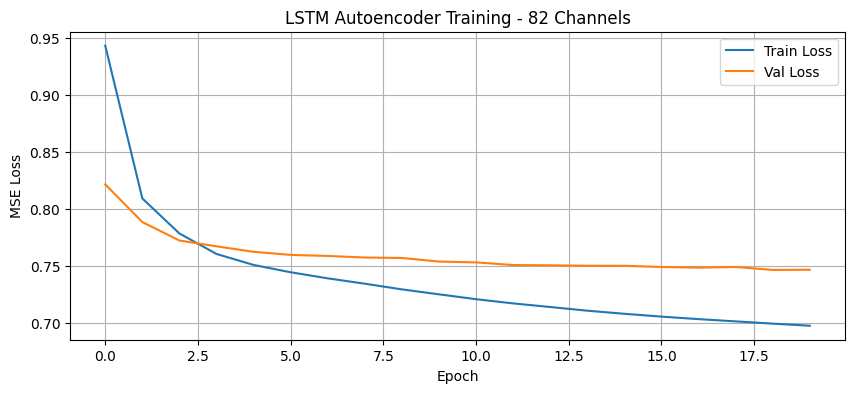

In [ ]:
# Cell 6: Training Loop
epochs = 20
train_losses = []
val_losses = []

print("🚀 Starting training...")
for epoch in range(epochs):
    # Training
    model.train()
    epoch_train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            reconstructed = model(batch)
            loss = criterion(reconstructed, batch)
            epoch_val_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    avg_val = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

# Plot training curve
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('LSTM Autoencoder Training - 82 Channels')
plt.grid(True)
plt.show()

✅ Computed 1550 validation errors.


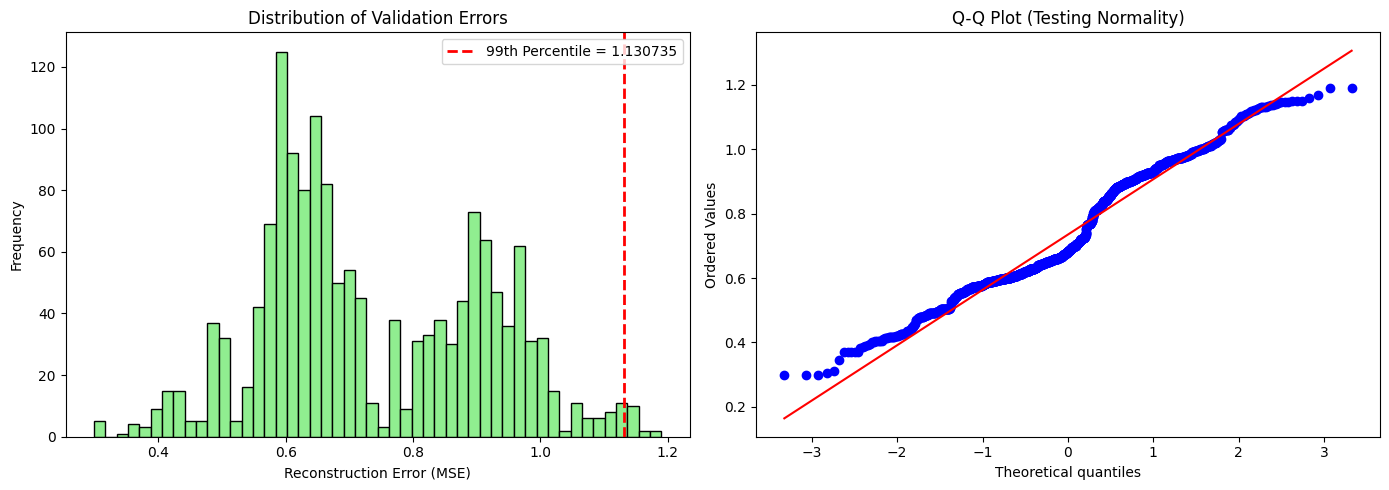


📊 99th Percentile Threshold: 1.130735
📊 Mean + 3*Std Threshold: 1.259666

📌 Why Percentile over Mean+3Std?
- The Q-Q plot shows if errors follow a Gaussian distribution.
- Sensor data errors are often skewed/heavy-tailed (non-normal).
- Percentile is non-parametric and robust to outliers in the error distribution.
- Mean+3Std assumes normality and will either over-flag or under-flag anomalies.


In [ ]:
# Cell 7: Calculate Reconstruction Errors & Choose Threshold
from scipy import stats

model.eval()
errors = []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        reconstructed = model(batch)
        # MSE per sample (average over time and channels)
        mse = torch.mean((reconstructed - batch) ** 2, dim=(1, 2)).cpu().numpy()
        errors.extend(mse)

errors = np.array(errors)
print(f"✅ Computed {len(errors)} validation errors.")

# Plot Error Distribution + Q-Q plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=50, edgecolor='black', color='lightgreen')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Frequency")
plt.title("Distribution of Validation Errors")

# Threshold: 99th percentile
threshold_percentile = np.percentile(errors, 99)
plt.axvline(threshold_percentile, color='red', linestyle='--', linewidth=2,
            label=f'99th Percentile = {threshold_percentile:.6f}')
plt.legend()

plt.subplot(1, 2, 2)
stats.probplot(errors, dist="norm", plot=plt)
plt.title("Q-Q Plot (Testing Normality)")

plt.tight_layout()
plt.show()

# Compare with Mean+3Std
mean_3std = np.mean(errors) + 3 * np.std(errors)

print(f"\n📊 99th Percentile Threshold: {threshold_percentile:.6f}")
print(f"📊 Mean + 3*Std Threshold: {mean_3std:.6f}")
print("\n📌 Why Percentile over Mean+3Std?")
print("- The Q-Q plot shows if errors follow a Gaussian distribution.")
print("- Sensor data errors are often skewed/heavy-tailed (non-normal).")
print("- Percentile is non-parametric and robust to outliers in the error distribution.")
print("- Mean+3Std assumes normality and will either over-flag or under-flag anomalies.")

In [ ]:
# Cell 8: Save Model for FastAPI Deployment
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/smap_msl_lstm_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'threshold': threshold_percentile,
    'input_dim': data_matrix.shape[1],
    'window_size': window_size
}, save_path)

print(f"✅ Model saved to: {save_path}")

Mounted at /content/drive
✅ Model saved to: /content/drive/MyDrive/smap_msl_lstm_model.pth


In [ ]:
# Cell 8.5: Download model directly to your local system
from google.colab import files

# Save to a temporary location on the Colab VM
temp_path = "/content/smap_msl_lstm_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'threshold': threshold_percentile,
    'input_dim': data_matrix.shape[1],
    'window_size': window_size
}, temp_path)

# This triggers a browser download to YOUR local machine
files.download(temp_path)

print("✅ The file is now downloading to your local machine's Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ The file is now downloading to your local machine's Downloads folder!
